# Implementacja drzewa czwórkowego (quadtree)

In [78]:
from visualizer.main import Visualizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(420)

Funkcja do interaktywnego rysowania punktów

In [79]:
all_drawn_points = []

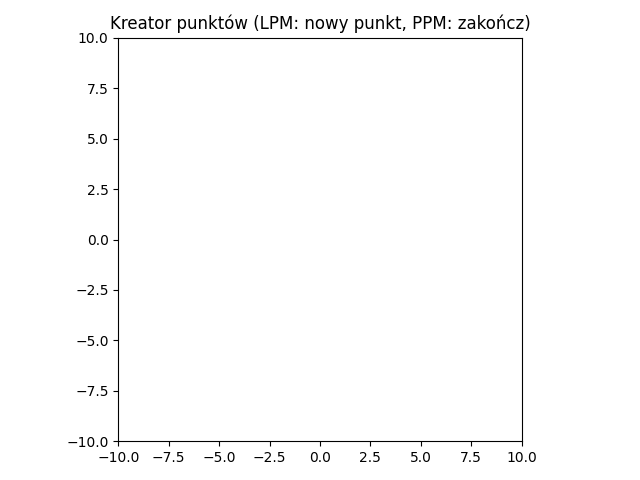

In [80]:
fig, ax = plt.subplots()

current_points = []

def onclick(event):
    global current_points

    if event.inaxes != ax:
        return

    # lewy przycisk myszy - dodaj punkt
    if event.button == 1:
        x, y = event.xdata, event.ydata
        current_points.append(Point(x, y))
        ax.plot(x, y, 'bo')
        fig.canvas.draw_idle()

    # prawy przycisk myszy - zakończ rysowanie
    elif event.button == 3:
        fig.canvas.mpl_disconnect(cid)
        plt.pause(0.5)
        plt.close(fig)

        all_drawn_points.append(current_points)

ax.set_title("Kreator punktów (LPM: nowy punkt, PPM: zakończ)")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
plt.tight_layout()

cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.ioff()

Funkcje pomocnicze do zapisu i odczytu punktów z pliku

In [81]:
def save_points(all_points):
    df = pd.DataFrame(columns=["Count of points", "Points"])
    for x ,points in enumerate(all_points):
        df.loc[x] = {
            "Count of points": len(points),
            "Points": points
        }
    df.to_csv("results/points.csv", index=False)

def read_points(filename):
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        return []

    all_points = []
    for index, row in df.iterrows():
        all_points.append(eval(row["Points"]))
    return all_points

In [82]:
if len(all_drawn_points) > 0:
    save_points(all_drawn_points)
else:
    all_drawn_points = read_points("results/points.csv")

Klasa reprezentująca punkt na płaszczyźnie 2D

In [83]:
class Point:
    def __init__(self, x: float, y: float):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x}, {self.y})"

    def __eq__(self, other):
        if not isinstance(other, Point):
            return False
        return self.x == other.x and self.y == other.y

    def __le__(self, other):
        if not isinstance(other, Point):
            return False
        return self.x <= other.x and self.y <= other.y

    def __ge__(self, other):
        if not isinstance(other, Point):
            return False
        return self.x >= other.x and self.y >= other.y

    def __hash__(self):
        return hash((self.x, self.y))

Klasa reprezentująca granice kwadratu na płaszczyźnie 2D

In [84]:
class Boundary:
    def __init__(self, ld: Point, rd: Point, ru: Point, lu: Point):
        invalid = (
            not (ld.x < rd.x) or
            not (ld.y < lu.y) or
            rd.y != ld.y or
            ru.x != rd.x or
            lu.x != ld.x or
            ru.y != lu.y or
            lu.y <= ld.y
        )
        if invalid:
            raise ValueError("Invalid boundary points")

        self.left_down = ld
        self.right_down = rd
        self.right_up = ru
        self.left_up = lu

    @classmethod
    def from_values(cls, x1: float, x2: float, y1: float, y2: float):
        ld = Point(x1, y1)
        rd = Point(x2, y1)
        ru = Point(x2, y2)
        lu = Point(x1, y2)
        return cls(ld, rd, ru, lu)

    def contains_point(self, p: Point, eps: float) -> bool:
        return (
            (self.left_down.x - eps) <= p.x <= (self.right_up.x + eps)
            and (self.left_down.y - eps) <= p.y <= (self.right_up.y + eps)
        )

    def to_list(self) -> list[tuple[float, float]]:
        return [(self.left_down.x, self.left_down.y),
                (self.right_down.x, self.right_down.y),
                (self.right_up.x, self.right_up.y),
                (self.left_up.x, self.left_up.y)]

    def intersects(self, other, eps: float) -> bool:
        if not isinstance(other, Boundary):
            return False
        return not (
            (self.right_up.x + eps) < other.left_down.x
            or (other.right_up.x + eps) < self.left_down.x
            or (self.right_up.y + eps) < other.left_down.y
            or (other.right_up.y + eps) < self.left_down.y
        )

    def visualize(self, vis=None, color='green') -> Visualizer:
        if not vis:
            vis = Visualizer()

        vis.add_polygon(self.to_list(), facecolor=None ,edgecolor=color, closed=True, linewidth=2, alpha=0.2)

        return vis

    def __repr__(self):
        return f"Boundary({self.left_down}, {self.right_down}, {self.right_up}, {self.left_up})"

Klasa reprezentująca strukturę quadtree

In [85]:
class Quadtree:
    def __init__(self, boundary: Boundary, points: list[Point] | None = None, capacity: int = 1, eps: float = 1e-9):
        if capacity < 1:
            raise ValueError("Capacity must be at least 1")

        self.boundary = boundary
        self.capacity = capacity
        self.points = []
        self.all_points = set()
        self.eps = eps

        self.left_down = None
        self.right_down = None
        self.right_up = None
        self.left_up = None

        if points:
            self.insert(points)

    @classmethod
    def from_points(cls, points: list[Point], capacity: int = 1, eps: float = 1e-9):
        boundary = Quadtree.get_max_boundary(points)
        return Quadtree(boundary, points, capacity, eps)

    @classmethod
    def from_float(cls, fl: list[tuple[float, float]], capacity: int = 1, eps: float = 1e-9):
        points = [Point(x, y) for x, y in fl]
        boundary = Quadtree.get_max_boundary(points)
        return Quadtree(boundary, points, capacity, eps)

    @staticmethod
    def get_max_boundary(points: list[Point]) -> Boundary:
        min_x = min(p.x for p in points)
        max_x = max(p.x for p in points)
        min_y = min(p.y for p in points)
        max_y = max(p.y for p in points)

        return Boundary(
            Point(min_x, min_y),
            Point(max_x, min_y),
            Point(max_x, max_y),
            Point(min_x, max_y)
        )

    def subdivide(self):
        mid_x = (self.boundary.left_down.x + self.boundary.right_up.x) / 2.0
        mid_y = (self.boundary.left_down.y + self.boundary.right_up.y) / 2.0

        self.left_down = Quadtree(
            Boundary(
                self.boundary.left_down,
                Point(mid_x, self.boundary.left_down.y),
                Point(mid_x, mid_y),
                Point(self.boundary.left_down.x, mid_y)
            ),
            capacity=self.capacity,
            eps=self.eps
        )

        self.right_down = Quadtree(
            Boundary(
                Point(mid_x, self.boundary.left_down.y),
                self.boundary.right_down,
                Point(self.boundary.right_up.x, mid_y),
                Point(mid_x, mid_y)
            ),
            capacity=self.capacity,
            eps=self.eps
        )

        self.right_up = Quadtree(
            Boundary(
                Point(mid_x, mid_y),
                Point(self.boundary.right_up.x, mid_y),
                self.boundary.right_up,
                Point(mid_x, self.boundary.left_up.y)
            ),
            capacity=self.capacity,
            eps=self.eps
        )

        self.left_up =  Quadtree(
            Boundary(
                Point(self.boundary.left_down.x, mid_y),
                Point(mid_x, mid_y),
                Point(mid_x, self.boundary.left_up.y),
                self.boundary.left_up
            ),
            capacity=self.capacity,
            eps=self.eps
        )

    def insert(self, point: list[Point] | Point) -> bool:
        if isinstance(point, list):
            return all(self.insert(p) for p in point)

        if not self.boundary.contains_point(point, self.eps):
            return False

        if point in self.all_points:
            return False

        self.all_points.add(point)

        if self.left_down is None:
            if len(self.points) < self.capacity:
                self.points.append(point)
                return True

            self.subdivide()

            for p in self.points:
                self._insert_to_all(p)

            self.points = []

        return self._insert_to_all(point)

    def _insert_to_all(self, point: Point) -> bool:
        return (self.left_down.insert(point) or self.right_down.insert(point) or
                self.right_up.insert(point) or self.left_up.insert(point))

    def get_all_points(self) -> set[Point]:
        if len(self.all_points) > 0:
            return self.all_points

        result = self.points.copy()

        if self.left_down:
            result.extend(self.left_down.get_all_points())
        if self.right_down:
            result.extend(self.right_down.get_all_points())
        if self.right_up:
            result.extend(self.right_up.get_all_points())
        if self.left_up:
            result.extend(self.left_up.get_all_points())

        return set(result)

    def search(self, boundary: Boundary) -> list[Point]:
        result = []

        if not boundary.intersects(self.boundary, self.eps):
            return result

        for p in self.points:
            if boundary.contains_point(p, self.eps):
                result.append(p)

        if self.left_down:
            result.extend(self.left_down.search(boundary))
        if self.right_down:
            result.extend(self.right_down.search(boundary))
        if self.right_up:
            result.extend(self.right_up.search(boundary))
        if self.left_up:
            result.extend(self.left_up.search(boundary))

        return result

Klasa wizualizująca strukturę quadtree oraz operacje wyszukiwania

In [104]:
class QuadtreeVisualizer(Visualizer):
    def __init__(self, tree: Quadtree):
        super().__init__()
        self.quadtree = tree
        self._visualize_quadtree(self.quadtree)

    def _visualize_quadtree(self, tree: Quadtree):
        self.add_point([(p.x, p.y) for p in self.quadtree.all_points], color='blue')

        def _visualize_subtree(subtree: Quadtree):
            subtree.boundary.visualize(self, color='green')

            if subtree.left_down:
                _visualize_subtree(subtree.left_down)
            if subtree.right_down:
                _visualize_subtree(subtree.right_down)
            if subtree.right_up:
                _visualize_subtree(subtree.right_up)
            if subtree.left_up:
                _visualize_subtree(subtree.left_up)

        _visualize_subtree(tree)

    def visualize_search(self, boundary: Boundary, color='red') -> Visualizer:
        boundary.visualize(self, color=color)

        found_points = self.quadtree.search(boundary)
        self.add_point([(p.x, p.y) for p in found_points], color='yellow')

        return self

    def visualize_search_with_steps(self, boundary: Boundary, color='red') -> Visualizer:
        boundary.visualize(self, color=color)

        def _visualize_search_step(tree: Quadtree):
            if not boundary.intersects(tree.boundary, tree.eps):
                return

            self.add_polygon(tree.boundary.to_list(), edgecolor='orange', facecolor=None, closed=True, linewidth=4, alpha=0.2)

            for p in tree.points:
                if boundary.contains_point(p, tree.eps):
                    self.add_point((p.x, p.y), color='yellow')

            if tree.left_down:
                _visualize_search_step(tree.left_down)
            if tree.right_down:
                _visualize_search_step(tree.right_down)
            if tree.right_up:
                _visualize_search_step(tree.right_up)
            if tree.left_up:
                _visualize_search_step(tree.left_up)

        _visualize_search_step(self.quadtree)

        boundary.visualize(self, color=color)
        return self

Funkcje generujące losowe punkty w zadanych granicach

In [87]:
def visualize_generators(n: int, func) -> Visualizer:
    boundary = Boundary.from_int(0, 50, 0, 50)
    random_points = func(boundary, n)
    vis = Visualizer()
    vis.add_point([(p.x, p.y) for p in random_points], color='blue')
    boundary.visualize(vis)
    return vis

Funkcja generująca losowe punkty w zadanych granicach

In [88]:
def generate_random_points(boundary: Boundary, n: int) -> list[Point]:
    points = []
    for _ in range(n):
        x = np.random.uniform(boundary.left_down.x, boundary.right_up.x)
        y = np.random.uniform(boundary.left_down.y, boundary.right_up.y)
        points.append(Point(x, y))
    return points

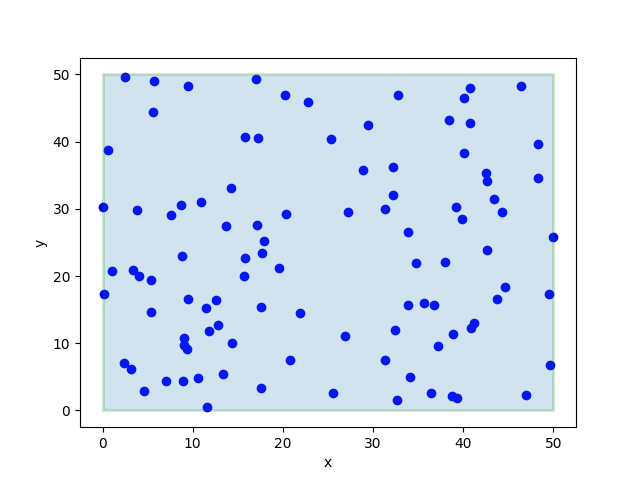

In [89]:
visualize_generators(100, generate_random_points).show()

Funkcja generująca punkty na przekątnej

In [90]:
def generate_collinear_points(boundary: Boundary, n: int) -> list[Point]:
    x1, y1 = boundary.left_down.x, boundary.left_down.y
    x2, y2 = boundary.right_up.x, boundary.right_up.y

    t_values = np.random.uniform(0, 1, n)
    points = [Point(x1 + t * (x2 - x1), y1 + t * (y2 - y1)) for t in t_values]
    return points

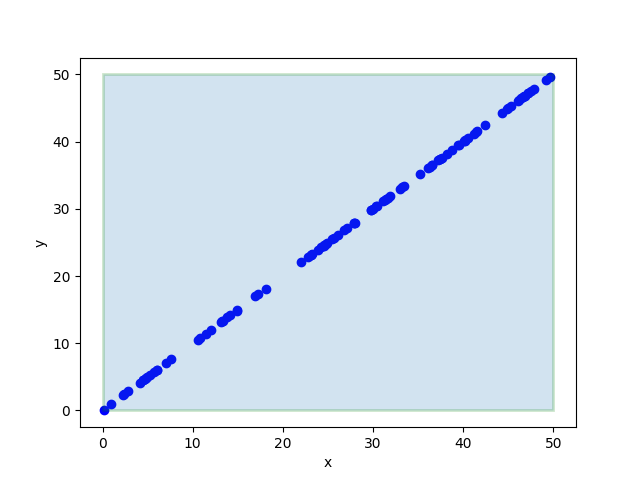

In [91]:
visualize_generators(100, generate_collinear_points).show()

Funkcja generująca punkty w trzech gęstych skupiskach

In [92]:
def generate_gesture_points(boundary: Boundary, n: int) -> list[Point]:
    width = boundary.right_up.x - boundary.left_down.x
    height = boundary.right_up.y - boundary.left_down.y

    # mniejszy = gęściej
    margin = 0.06 * min(width, height)

    centers = [
        Point(
            np.random.uniform(boundary.left_down.x, boundary.right_up.x),
            np.random.uniform(boundary.left_down.y, boundary.right_up.y),
        )
        for _ in range(3)
    ]

    base = n // 3
    counts = [base, base, n - 2 * base]

    points: list[Point] = []
    for c, k in zip(centers, counts):
        for _ in range(k):
            x = c.x + np.random.uniform(-margin, margin)
            y = c.y + np.random.uniform(-margin, margin)

            x = float(np.clip(x, boundary.left_down.x, boundary.right_up.x))
            y = float(np.clip(y, boundary.left_down.y, boundary.right_up.y))

            points.append(Point(x, y))

    return points

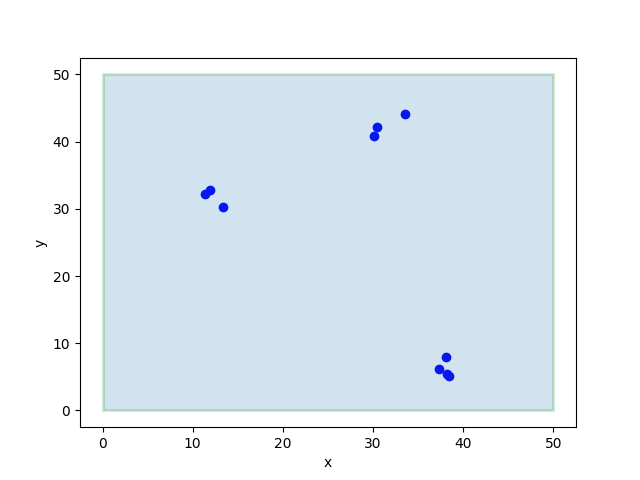

In [93]:
visualize_generators(10, generate_gesture_points).show()

Funkcja generująca punkty na krawędziach prostokąta

In [94]:
def generate_rectangle_points(boundary: Boundary, n: int) -> list[Point]:
    a = (boundary.left_down.x, boundary.left_down.y)
    b = (boundary.right_up.x, boundary.left_down.y)
    c = (boundary.right_up.x, boundary.right_up.y)
    d = (boundary.left_down.x, boundary.right_up.y)
    points = []
    for _ in range(n):
        side = np.random.randint(0, 4)
        t = np.random.uniform(0, 1)
        if side == 0:
            x = a[0] + t * (b[0] - a[0])
            y = a[1]
        elif side == 1:
            x = b[0]
            y = b[1] + t * (c[1] - b[1])
        elif side == 2:
            x = c[0] + t * (d[0] - c[0])
            y = c[1]
        else:
            x = d[0]
            y = d[1] + t * (a[1] - d[1])
        points.append(Point(x, y))

    return points

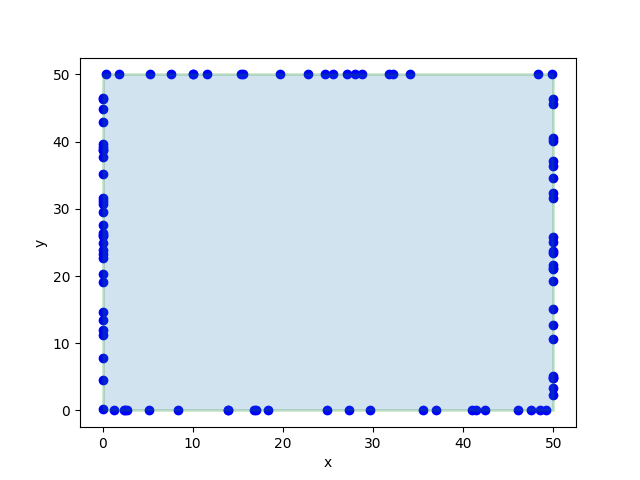

In [95]:
visualize_generators(100, generate_rectangle_points).show()

Funkcja generująca punkty na dolnej krawędzi prostokąta

In [96]:
def generate_one_edge_points(boundary: Boundary, n: int) -> list[Point]:
    a = (boundary.left_down.x, boundary.left_down.y)
    b = (boundary.right_up.x, boundary.left_down.y)
    points = []
    for _ in range(n):
        t = np.random.uniform(0, 1)
        x = a[0] + t * (b[0] - a[0])
        y = a[1]
        points.append(Point(x, y))
    return points

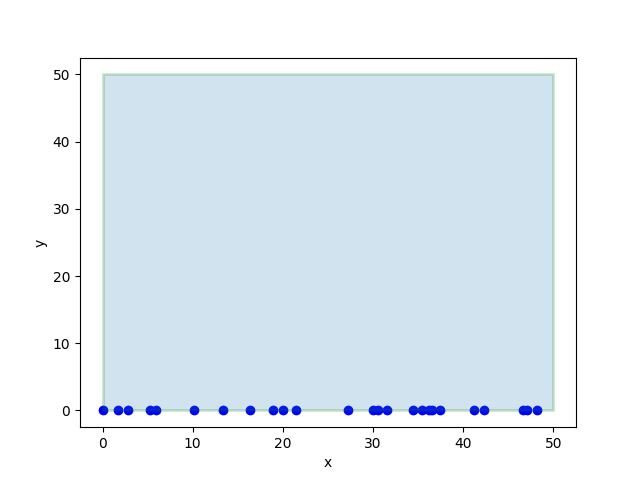

In [97]:
visualize_generators(25, generate_one_edge_points).show()

Przykładowa wizualizacja drzewa czwórkowego oraz operacji wyszukiwania

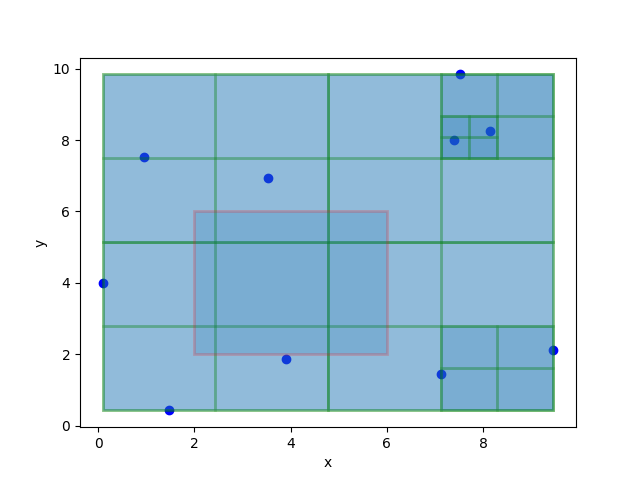

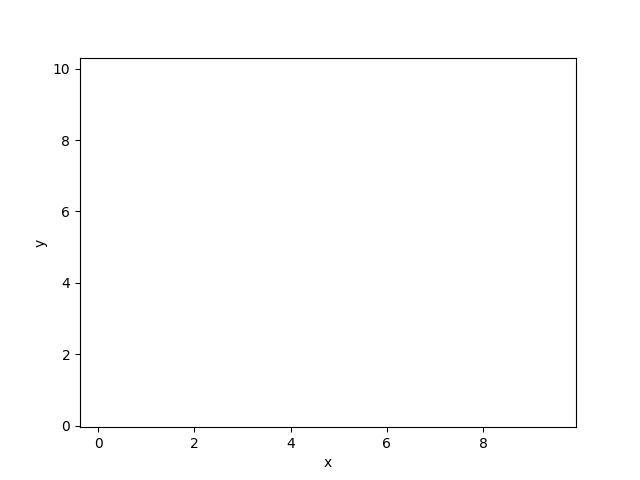

In [105]:
points = generate_random_points(Boundary.from_int(0, 10, 0, 10), 10)
tree = Quadtree.from_points(points)
search_boundary = Boundary.from_int(2, 6, 2, 6)
QuadtreeVisualizer(tree).show()
QuadtreeVisualizer(tree).visualize_search(search_boundary).show()

QuadtreeVisualizer(tree).visualize_search_with_steps(search_boundary).show_gif(interval=600)

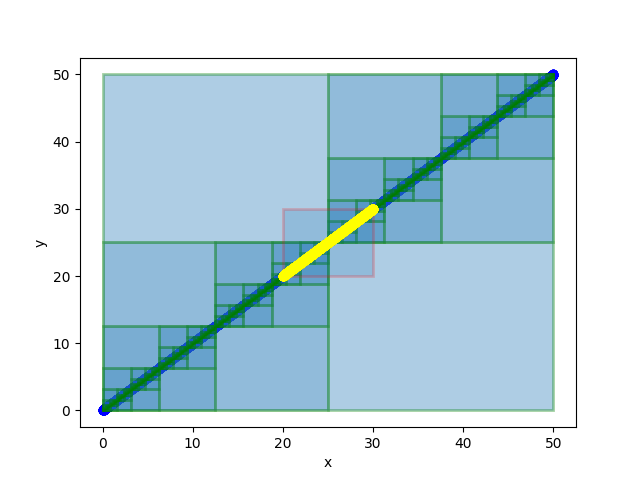

Points found: 2068


In [101]:
boundary = Boundary.from_int(0, 50, 0, 50)
points = generate_collinear_points(boundary, 1000)

tree = Quadtree(boundary, points)
vis_tree = QuadtreeVisualizer(tree)
search_boundary = Boundary.from_int(20, 30, 20, 30)
vis_tree.visualize_search(search_boundary).show()

print("Points found:", len(tree.search(search_boundary)))